In [1]:
import pandas as pd
import os
from pathlib import Path
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

Tamaño de X_train: 39
Tamaño de y_train: 39
Coeficiente (pendiente): [0.50657985]
Intercepto: 9.821767189285374


C:\Users\ntrig\AppData\Local\Temp\ipykernel_27588\3983368939.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2019['epiweek_shifted'] = hospitalizations_2019['epiweek']


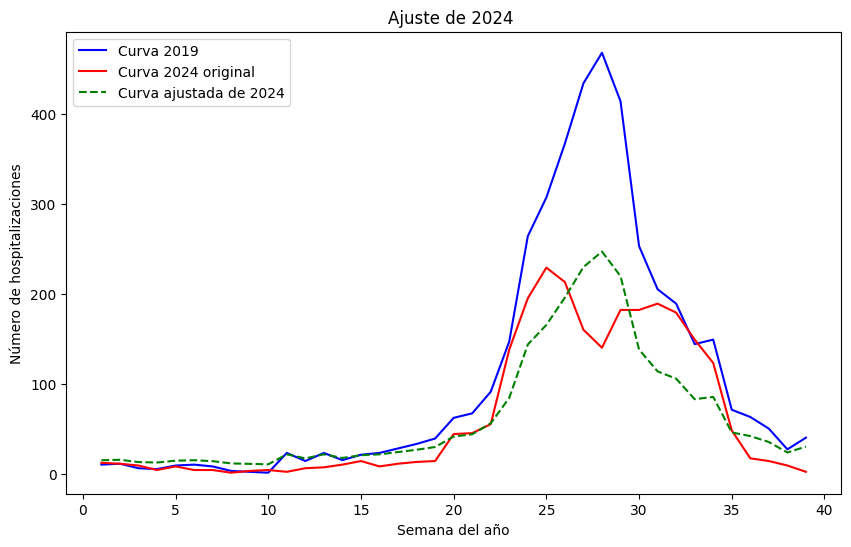

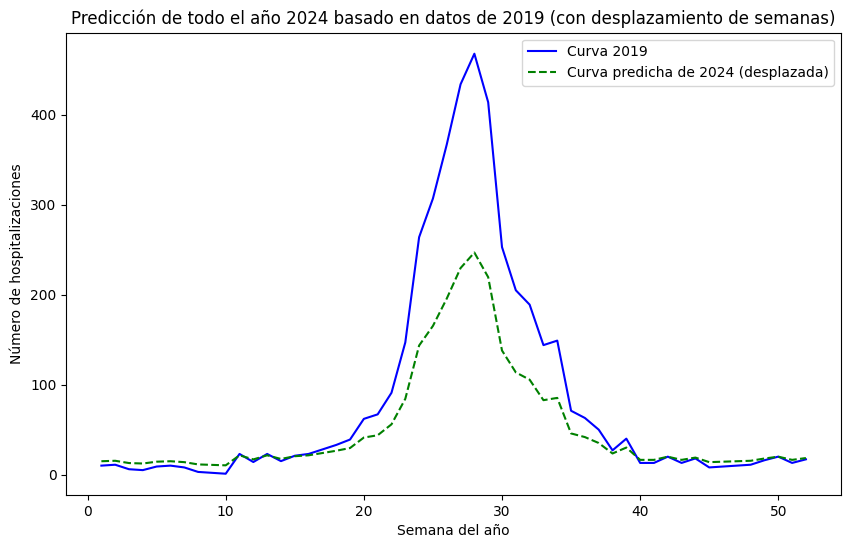

Las hospitalizaciones ahorradas totales son: 47.56709438227768


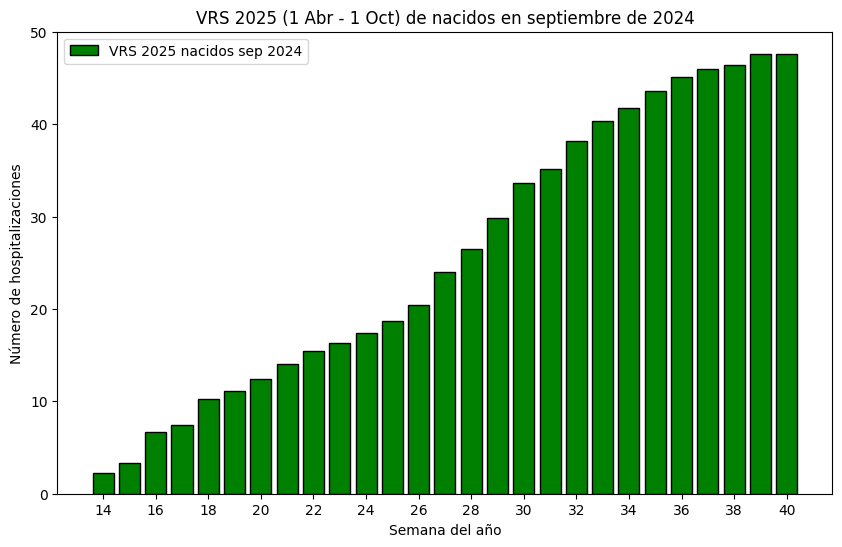

In [11]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df = pd.read_csv(path_data/"data.csv")
df = (df
      .drop(columns=['Unnamed: 0'])
      .query('2021<year | year<=2020')
      .assign(FECHA_NAC = pd.to_datetime(df['FECHA_NAC'], errors='coerce'),
              nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2019) & (x.FECHA_NAC.dt.month == 11), 1, 0),
              nac_sep=lambda x: np.where((x.FECHA_NAC.dt.year == 2018) & (x.FECHA_NAC.dt.month == 9), 1, 0))
      .copy()
)
regiones = df.region.unique()
hospitalizations_by_week = df.groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
hospitalizations_by_week_elegibles = df.query('elegibilidad==year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
hospitalizations_by_week_non_elegibles = df.query('elegibilidad!=year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

data = hospitalizations_by_week_non_elegibles.copy()

hospitalizations_2019 = data[data['year'] == 2019]

hospitalizations_2024 = data[data['year'] == 2024]

hospitalizations_2019['epiweek_shifted'] = hospitalizations_2019['epiweek'] 

epiweeks_2024 = hospitalizations_2024['epiweek'].unique()  
hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek_shifted'].isin(epiweeks_2024)]  

hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek_shifted'])]

X_train = hospitalizations_2019_train['hospitalizations'].values.reshape(-1, 1)
y_train = hospitalizations_2024_train['hospitalizations'].values

print(f"Tamaño de X_train: {len(X_train)}")
print(f"Tamaño de y_train: {len(y_train)}")

model = LinearRegression()
model.fit(X_train, y_train)

coeficiente = model.coef_  
intercepto = model.intercept_  

print(f"Coeficiente (pendiente): {coeficiente}")
print(f"Intercepto: {intercepto}")

predicted_2024 = model.predict(X_train)

plt.figure(figsize=(10,6))

plt.plot(hospitalizations_2019_train['epiweek'], hospitalizations_2019_train['hospitalizations'], label='Curva 2019', color='blue')

plt.plot(hospitalizations_2024_train['epiweek'], hospitalizations_2024_train['hospitalizations'], label='Curva 2024 original', color='red')

plt.plot(hospitalizations_2019_train['epiweek_shifted'], predicted_2024, label='Curva ajustada de 2024', linestyle='--', color='green')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Ajuste de 2024 ')
plt.legend()
plt.show()

hospitalizations_2019_full = data.query('year==2019').copy()

hospitalizations_2019_full['epiweek_shifted'] = hospitalizations_2019_full['epiweek']

# Usar las hospitalizaciones de 2019 desplazadas como entrada para predecir todo 2024
X_full = hospitalizations_2019_full['hospitalizations'].values.reshape(-1, 1)

# Predecir usando el modelo ya entrenado
predicted_2024_full = model.predict(X_full)

# Graficar las hospitalizaciones originales de 2019 y las predicciones para 2024
plt.figure(figsize=(10,6))

# Graficar las hospitalizaciones originales de 2019
plt.plot(hospitalizations_2019_full['epiweek'], hospitalizations_2019_full['hospitalizations'], label='Curva 2019', color='blue')

# Graficar las predicciones de 2024
plt.plot(hospitalizations_2019_full['epiweek_shifted'], predicted_2024_full, label='Curva predicha de 2024 (desplazada)', linestyle='--', color='green')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Predicción de todo el año 2024 basado en datos de 2019 (con desplazamiento de semanas)')
plt.legend()

# Mostrar el gráfico
plt.show()
df_note = df.copy().query('elegibilidad!=year')

hospitalizations_total = df_note.groupby(['year', 'epiweek']).size().reset_index(name='total_hospitalizations')

hospitalizations_sep = df_note[df_note['nac_sep'] == 1].groupby(['year', 'epiweek']).size().reset_index(name='sep_hosptialization')

hospitalizations = pd.merge(hospitalizations_total, hospitalizations_sep, on=['year', 'epiweek'], how='left')

hospitalizations['sep_hosptialization'] = hospitalizations['sep_hosptialization'].fillna(0)

hospitalizations['percentage_sep'] = (hospitalizations['sep_hosptialization'] / hospitalizations['total_hospitalizations']) * 100

weeks_2024 = hospitalizations.query('year==2019')['epiweek'].unique() 

X_full = hospitalizations.query('year==2019')['sep_hosptialization'].values.reshape(-1, 1)

predicted_2024_full = model.predict(X_full)

predictions_df = pd.DataFrame({
    'epiweek': weeks_2024,
    'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
})

hospitalizations_merged = hospitalizations.query('year==2019').merge(predictions_df, on='epiweek', how='left')

hospitalizations_merged['predicted_sep_2024'] = (hospitalizations_merged['percentage_sep'] / 100) * hospitalizations_merged['predicted_2024']

hospitalizations_merged = hospitalizations_merged[['year', 'epiweek', 'total_hospitalizations', 'predicted_2024', 'percentage_sep', 'predicted_sep_2024']]

hospitalizations_filtered = hospitalizations_merged[(hospitalizations_merged['epiweek'] >= 14) & (hospitalizations_merged['epiweek'] <= 40)]

print(f"Las hospitalizaciones ahorradas totales son: {hospitalizations_filtered['predicted_sep_2024'].cumsum().max()}")

plt.figure(figsize=(10,6))


plt.bar(hospitalizations_filtered['epiweek'], hospitalizations_filtered['predicted_sep_2024'].cumsum(), color='green', edgecolor='black', label='VRS 2025 nacidos sep 2024')


plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('VRS 2025 (1 Abr - 1 Oct) de nacidos en septiembre de 2024')


plt.xticks(np.arange(14, 41, 2))
plt.yticks(np.arange(0, hospitalizations_filtered['predicted_sep_2024'].cumsum().max() + 10, 10))

plt.legend()

plt.show()


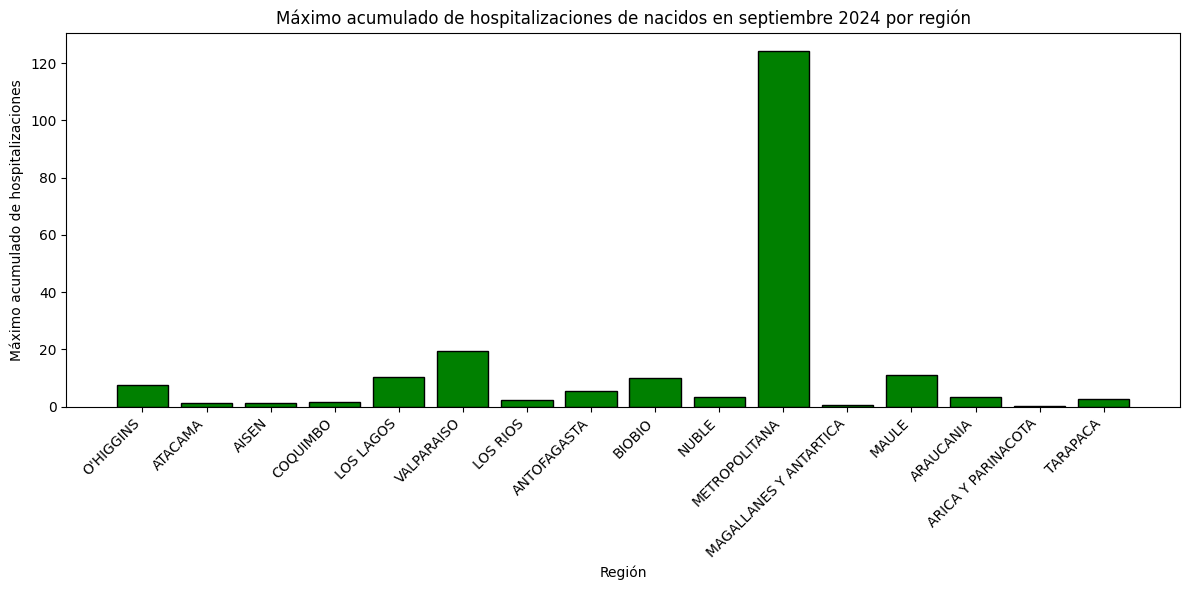

In [57]:
hospitalizations_total = (df
                          .query('elegibilidad!=year')
                          .groupby(['year', 'epiweek', 'region'])
                          .size().reset_index(name='hospitalizations')
                          .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                          .reset_index()
                          .copy()
)

hospitalizations_nov = (df
                        .query('elegibilidad!=year')
                        .query('nac_sep == 1')
                        .groupby(['year', 'epiweek', 'region'])
                        .size()
                        .reset_index(name='hospitalizations')
                        .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                        .reindex(columns=regiones, fill_value=0)  
                        .reset_index()
                        .copy()
)



max_cumsum_by_region_septiembre = {}

for i in regiones:   

    hospitalizations_reg = hospitalizations_total[['year', 'epiweek', i]].copy().rename(columns = {i:'regional_hospitalizations'})
    hospitalizations_sep_reg = hospitalizations_nov[['year', 'epiweek',i]].copy().rename(columns = {i:'sep_hosptialization'})
    
    hospitalizations = pd.merge(hospitalizations_reg, hospitalizations_sep_reg, on=['year', 'epiweek'], how='left')
    hospitalizations['sep_hosptialization'] = hospitalizations['sep_hosptialization'].fillna(0)
    hospitalizations['percentage_sep'] = (hospitalizations['sep_hosptialization'] / hospitalizations['regional_hospitalizations']) * 100
    
    
    
    hospitalizations_2019 = hospitalizations[hospitalizations['year'] == 2019]
    hospitalizations_2024 = hospitalizations[hospitalizations['year'] == 2024]
    epiweeks_2024 = hospitalizations_2024['epiweek'].unique() 
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek'].isin(epiweeks_2024)]  
    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek'])]
    
    X_train = hospitalizations_2019_train.query('year==2019')['regional_hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train.query('year==2024')['regional_hospitalizations'].values
    

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    
    weeks_2024 = hospitalizations.query('year==2019 & 14<=epiweek<=40')['epiweek'].unique() 
    X_full = hospitalizations.query('year==2019 & 14<=epiweek<=40')['regional_hospitalizations'].values.reshape(-1, 1)
    predicted_2024_full = model.predict(X_full)
    
    predictions_df = pd.DataFrame({
        'epiweek': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })
    hospitalizations_merged = hospitalizations.query('year==2019 & 14<=epiweek<=40').merge(predictions_df, on='epiweek', how='left')
    hospitalizations_merged['predicted_sep_2024'] = (hospitalizations_merged['percentage_sep'] / 100) * hospitalizations_merged['predicted_2024']
    

    max_cumsum_by_region_septiembre[i] = hospitalizations_merged['predicted_sep_2024'].cumsum().max()

plt.figure(figsize=(12, 6))

plt.bar(max_cumsum_by_region_septiembre.keys(), max_cumsum_by_region_septiembre.values(), color='green', edgecolor='black')


plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones de nacidos en septiembre 2024 por región')


plt.xticks(rotation=45, ha='right')  


plt.tight_layout()  
plt.show()

C:\Users\ntrig\AppData\Local\Temp\ipykernel_10576\2578922675.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2019['epiweek_shifted'] = hospitalizations_2019['epiweek']
C:\Users\ntrig\AppData\Local\Temp\ipykernel_10576\2578922675.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2019['epiweek_shifted'] = hospitalizations_2019['epiweek']
C:\Users\ntrig\AppData\Local\Temp\ipykernel_10576\2578922675.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy o

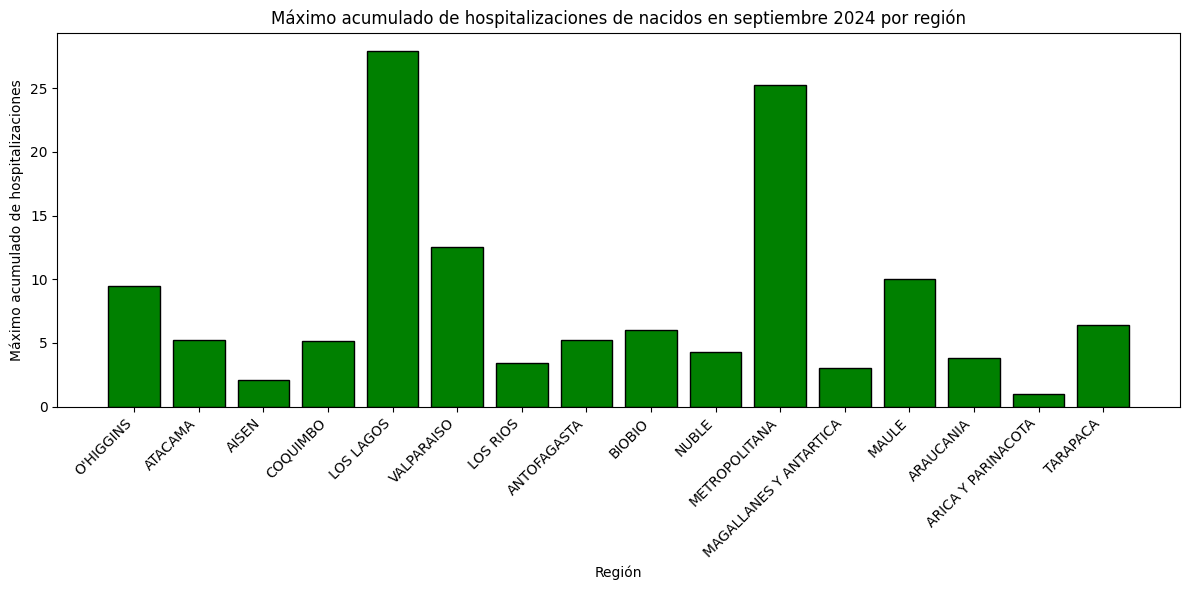

In [61]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df_all = pd.read_csv(path_data/"data.csv")
regiones = df_all.region.unique()

max_cumsum_by_region_septiembre = {}


for i in regiones:
    df = df_all.copy()
    df = (df
        .query(f'region=="{i}"')
        .drop(columns=['Unnamed: 0'])
        .query('2021<year | year<=2020')
        .assign(FECHA_NAC = pd.to_datetime(df['FECHA_NAC'], errors='coerce'),
                nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2019) & (x.FECHA_NAC.dt.month == 11), 1, 0),
                nac_sep=lambda x: np.where((x.FECHA_NAC.dt.year == 2018) & (x.FECHA_NAC.dt.month == 9), 1, 0))
        .copy()
    )

    hospitalizations_by_week = df.groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
    hospitalizations_by_week_elegibles = df.query('elegibilidad==year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
    hospitalizations_by_week_non_elegibles = df.query('elegibilidad!=year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

    data = hospitalizations_by_week_non_elegibles.copy()

    hospitalizations_2019 = data[data['year'] == 2019]

    hospitalizations_2024 = data[data['year'] == 2024]

    hospitalizations_2019['epiweek_shifted'] = hospitalizations_2019['epiweek']

    epiweeks_2024 = hospitalizations_2024['epiweek'].unique()  
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek_shifted'].isin(epiweeks_2024)]  

    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek_shifted'])]

    X_train = hospitalizations_2019_train['hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['hospitalizations'].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    coeficiente = model.coef_  
    intercepto = model.intercept_  

    predicted_2024 = model.predict(X_train)


    hospitalizations_2019_full = data.query('year==2019').copy()

    hospitalizations_2019_full['epiweek_shifted'] = hospitalizations_2019_full['epiweek']

    # Usar las hospitalizaciones de 2019 desplazadas como entrada para predecir todo 2024
    X_full = hospitalizations_2019_full['hospitalizations'].values.reshape(-1, 1)

    # Predecir usando el modelo ya entrenado
    predicted_2024_full = model.predict(X_full)

    df_note = df.query('elegibilidad!=year')

    hospitalizations_total = df_note.groupby(['year', 'epiweek']).size().reset_index(name='total_hospitalizations')

    hospitalizations_sep = df_note[df_note['nac_sep'] == 1].groupby(['year', 'epiweek']).size().reset_index(name='sep_hosptialization')

    hospitalizations = pd.merge(hospitalizations_total, hospitalizations_sep, on=['year', 'epiweek'], how='left')

    hospitalizations['sep_hosptialization'] = hospitalizations['sep_hosptialization'].fillna(0)

    hospitalizations['percentage_sep'] = (hospitalizations['sep_hosptialization'] / hospitalizations['total_hospitalizations']) * 100

    weeks_2024 = hospitalizations.query('year==2019')['epiweek'].unique() 

    X_full = hospitalizations.query('year==2019')['sep_hosptialization'].values.reshape(-1, 1)

    predicted_2024_full = model.predict(X_full)

    predictions_df = pd.DataFrame({
        'epiweek': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })

    hospitalizations_merged = hospitalizations.query('year==2019').merge(predictions_df, on='epiweek', how='left')

    hospitalizations_merged['predicted_sep_2024'] = (hospitalizations_merged['percentage_sep'] / 100) * hospitalizations_merged['predicted_2024']

    hospitalizations_merged = hospitalizations_merged[['year', 'epiweek', 'total_hospitalizations', 'predicted_2024', 'percentage_sep', 'predicted_sep_2024']]

    hospitalizations_filtered = hospitalizations_merged[(hospitalizations_merged['epiweek'] >= 14) & (hospitalizations_merged['epiweek'] <= 40)]
  
    max_cumsum_by_region_septiembre[i] = hospitalizations_filtered['predicted_sep_2024'].cumsum().max()
    
    
plt.figure(figsize=(12, 6))

plt.bar(max_cumsum_by_region_septiembre.keys(), max_cumsum_by_region_septiembre.values(), color='green', edgecolor='black')


plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones de nacidos en septiembre 2024 por región')


plt.xticks(rotation=45, ha='right')  


plt.tight_layout()  
plt.show()
